# Uncertanty Propagation MCDA
Here I test three approach to propagate the uncertanty in a MCDA framework

## Data Input

In [5]:
import numpy as np
from scipy.interpolate import PchipInterpolator

# Criteria names
criteria = ["C1", "C2", "C3", "C4", "C5"]

# Define alternatives
alternative_A = [9, {"Normal": [7, 0.7]}, {"Discrete": [8, 8, 7]}, {"Uniform": [2, 3]}, {"Triangular": [1, 2, 3]}]  # Criterion values for alternative A
alternative_B = [6, {"Normal": [6, 0.6]}, {"Discrete": [7, 8, 6]}, {"Uniform": [1, 2]}, {"Triangular": [1, 1.5, 2]}]  # Criterion values for alternative B
alternative_C = [2, {"Normal": [3, 0.3]}, {"Discrete": [9, 6, 8]}, {"Uniform": [3, 6]}, {"Triangular": [2, 3, 4]}]  # Criterion values for alternative C
alternatives = [alternative_A, alternative_B, alternative_C]

weights = [
    [(0.2, 0.25), (0.21, 0.26), (0.19, 0.24), (0.22, 0.27)],  # Criterion 1
    [(0.23, 0.3), (0.24, 0.31), (0.22, 0.29), (0.25, 0.32)],   # Criterion 2
    [(0.3, 0.4), (0.31, 0.41), (0.29, 0.39), (0.32, 0.42)],   # Criterion 3
    [(0.25, 0.35), (0.26, 0.36), (0.24, 0.34), (0.27, 0.37)],    # Criterion 4
    [(0.15, 0.2), (0.16, 0.21), (0.14, 0.19), (0.17, 0.22)]     # Criterion 5
]

# Results of value function elicitation
C1_vf_a_points = [0, 3, 5, 6, 10]
C1_vf_b_points = [0, 2, 4, 7, 10]
C2_vf_a_points = [0, 4, 6, 8, 10]
C2_vf_b_points = [0, 3, 5, 7, 10]
C3_vf_a_points = [0, 2, 7, 9, 10]
C3_vf_b_points = [0, 1, 6, 8, 10]
C4_vf_a_points = [0, 1, 4, 6, 10]
C4_vf_b_points = [0, 2, 5, 7, 10]
C5_vf_a_points = [0, 2, 5, 8, 10]
C5_vf_b_points = [0, 1, 4, 7, 10]

elicitation_values = [0, 0.25, 0.5, 0.75, 1]
def value_function(*points):
    value_functions = []
    for point in points:
        vf = PchipInterpolator(point, elicitation_values)
        value_functions.append(vf)

    return value_functions

vf_C1 = value_function(C1_vf_a_points, C1_vf_b_points)
vf_C2 = value_function(C2_vf_a_points, C2_vf_b_points)
vf_C3 = value_function(C3_vf_a_points, C3_vf_b_points)
vf_C4 = value_function(C4_vf_a_points, C4_vf_b_points)
vf_C5 = value_function(C5_vf_a_points, C5_vf_b_points)

vf_list = [vf_C1, vf_C2, vf_C3, vf_C4, vf_C5]

## MC-RSS Method
This method is primarly based on the error propagation by means of the root sum square method. To do so we assume all uncertanties can be expressed in the form $\mu \pm \sigma$, therefore assuming all distribution are normal distributions. The MC component is used to compute $v(x)$ since $x$, the input data, is normally distributed but we also have to consider that the value function $v$ return a normal distirbution for each input. For this we therefore sample by means of Montecarlo code to then assume the resulting distribution is again a normal one. 

The result is a very quick computation that returns the alternative value $A$ in terms of $\mu \pm \sigma$

In [6]:
from up_mavt import mc_rss_mavt
results_MC_RSS = mc_rss_mavt(alternatives, vf_list, weights, mc_simulations=10000)

## Fully Montecarlo: NSMC and SMC Methods
Here we drop the previous hypotesis of normally distributed data to instead propagate the uncertanty as is.
The montecarlo approach has to variants: Non-Strict and Strict  
In the Non-Strict (NSMC) we create distributions based on the available data, under the assumption that the elicited information is a small discrete set of a continuos reality. For instance if we elicited two possible value fuctions we might assume an uniform distribution of values between them, or a normal one. 

On the other hand, for the Strict method (SMC) no further assumptions are made, elicited information is used "as-is" to preserve the discrete nature of the elicitation process. In other words if we have two possible value functions we can only sample between 2 values.

The semplicity of the SMC method is shown by its higher computational speed, while the NSMC take almost double the time.

In [7]:
from up_mavt import mc_simulation
from up_mavt import weighted_sum, geometric_mean, harmonic_mean, minimum, maximum
sim_runs = 1000000
sampling_bins = 100
args = (alternatives, vf_list, [np.load("posterior_samples.npy")], weighted_sum, sim_runs, sampling_bins)

In [8]:
results_MC_strict, rel_err_MC_strict = mc_simulation(*args, strict = True, strict_d = True)
results_MC_strict = results_MC_strict[0]
rel_err_MC_strict = rel_err_MC_strict[0]
print(f"MC Error: {np.mean(rel_err_MC_strict)*100} %")

MC Error: 0.009188687521024055 %


In [9]:
results_MC_non_strict, rel_err_MC_non_strict = mc_simulation(*args, strict = False, strict_d=False)
results_MC_non_strict = results_MC_non_strict[0]
rel_err_MC_non_strict = rel_err_MC_non_strict[0]
print(f"MC Error: {np.mean(rel_err_MC_non_strict)*100} %")

MC Error: 0.007730284035894748 %


## Comparison
By assuming normal distributions for the NSMC we obtain, as expected, the same result as the MC-RSS method, with a slightly smaller relative uncertanty. With that said the computational time required to run the NSMC is close to one order of magnitude higher then the MC-RSS. This was expected as the NSMC was not intended to serve as a viable alternative but rather to verify the coherence between the analyitical and the numerical approach.

On the other hand, the SMC provides slightly different results, for the final analysis we will compare the results of the MC-RSS to the SMC. The main interest is to see if it is possible to obtain resonable results with a quick, almost perfectly analytical method.

In [10]:
for i, r_rss in enumerate(results_MC_RSS):
    print(f"Alternative {chr(65+results_MC_RSS.index(r_rss))}: Total Weighted Value (RSS) = {r_rss}")
    print(f"Alternative {chr(65+i)}: Total Weighted Value (FS-MC) = {np.mean(results_MC_strict[:, i])} ± {np.std(results_MC_strict[:, i])}")
    print(f"Alternative {chr(65+i)}: Total Weighted Value (NS-MC) = {np.mean(results_MC_non_strict[:, i])} ± {np.std(results_MC_non_strict[:, i])}")
    print("--------------------------------------------------")


Alternative A: Total Weighted Value (RSS) = 0.597101 ± 0.0548527
Alternative A: Total Weighted Value (FS-MC) = 0.6157524402449303 ± 0.036830281577786145
Alternative A: Total Weighted Value (NS-MC) = 0.4375855219622483 ± 0.031348336762618334
--------------------------------------------------
Alternative B: Total Weighted Value (RSS) = 0.47349 ± 0.0465298
Alternative B: Total Weighted Value (FS-MC) = 0.48339350312385426 ± 0.03612834050076977
Alternative B: Total Weighted Value (NS-MC) = 0.3492098839328823 ± 0.025983848328400026
--------------------------------------------------
Alternative C: Total Weighted Value (RSS) = 0.46015 ± 0.0530062
Alternative C: Total Weighted Value (FS-MC) = 0.2558098453988061 ± 0.03609682721875725
Alternative C: Total Weighted Value (NS-MC) = 0.28740403154984395 ± 0.02467694934415928
--------------------------------------------------


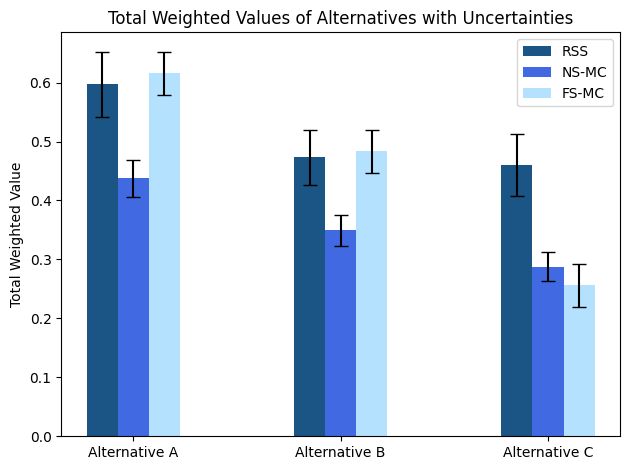

In [11]:
import matplotlib.pyplot as plt

labels = [f"Alternative {chr(65+i)}" for i in range(len(alternatives))]
values_rss = [res.value for res in results_MC_RSS]
values_smc = [np.mean(results_MC_strict[:, i]) for i in range(results_MC_strict.shape[1])]
values_nsmc = [np.mean(results_MC_non_strict[:, i]) for i in range(results_MC_non_strict.shape[1])]

uncertainties_rss = [res.uncertainty for res in results_MC_RSS]
uncertainties_smc = [np.std(results_MC_strict[:, i]) for i in range(results_MC_strict.shape[1])]
uncertainties_nsmc = [np.std(results_MC_non_strict[:, i]) for i in range(results_MC_non_strict.shape[1])]


x = np.arange(len(labels))
width = 0.15
fig, ax = plt.subplots()

# Order bars as: RSS, NS-MC, Partial Strict W, Partial Strict V, FS-MC
bars_rss = ax.bar(x - width, values_rss, width, yerr=uncertainties_rss, capsize=5, label='RSS', color="#1A5585", ecolor='black')
bars_nsmc = ax.bar(x, values_nsmc, width, yerr=uncertainties_nsmc, capsize=5, label='NS-MC', color='#4169E1', ecolor='black')
bars_smc = ax.bar(x + width, values_smc, width, yerr=uncertainties_smc, capsize=5, label='FS-MC', color="#B4E1FD", ecolor='black')

ax.set_ylabel('Total Weighted Value')
ax.set_title('Total Weighted Values of Alternatives with Uncertainties')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

Show the difference between strict and normally distributed

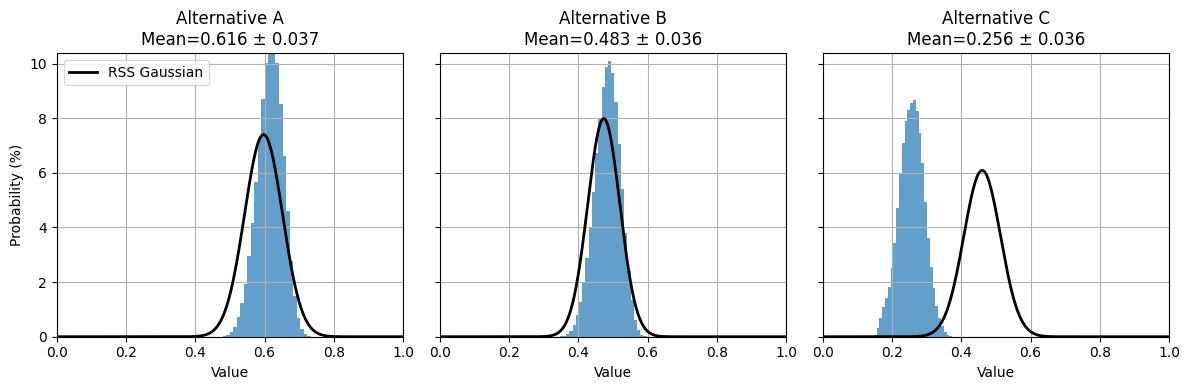

In [12]:
# plot all alternatives in one figure using subplots and overlay RSS as Gaussians
n = len(alternatives)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

# prepare RSS stats
rss_means = [m.value for m in results_MC_RSS]
rss_sigmas = [m.uncertainty for m in results_MC_RSS]

for alt_idx, ax in enumerate(axes):
    data = results_MC_strict[:, alt_idx]

    hist, bin_edges = np.histogram(data, bins=30)
    hist_prob = hist / sim_runs  # probability per bin (sums to 1)
    mean_value = np.mean(data)
    std_value = np.std(data)

    ax.bar(bin_edges[:-1], hist_prob * 100, width=np.diff(bin_edges), align='edge', alpha=0.7)
    ax.set_xlabel("Value")
    ax.set_xlim(0, 1)
    ax.set_ylabel("Probability (%)" if alt_idx == 0 else "")
    ax.set_title(f"Alternative {chr(65 + alt_idx)}\nMean={mean_value:.3f} ± {std_value:.3f}")
    ax.grid(True)
    ax.set_ylim(0, max(hist_prob * 100) * 1.2)

    # overlay RSS as Gaussian (scaled to match histogram percentage per bin)
    mean_rss = rss_means[alt_idx]
    sigma_rss = rss_sigmas[alt_idx]
    bin_width = np.mean(np.diff(bin_edges))
    x_pdf = np.linspace(0, 1, 400)
    # avoid div by zero if sigma is zero
    if sigma_rss <= 0:
        ax.axvline(mean_rss, color='k', linestyle='--', label='RSS (mean)')
    else:
        pdf = np.exp(-0.5 * ((x_pdf - mean_rss) / sigma_rss) ** 2) / (sigma_rss * np.sqrt(2 * np.pi))
        # scale pdf to percentage per bin to match bar heights
        pdf_scaled = pdf * 100 * bin_width
        ax.plot(x_pdf, pdf_scaled, color='black', lw=2, label='RSS Gaussian')

# add a single legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend()

plt.tight_layout()
plt.show()

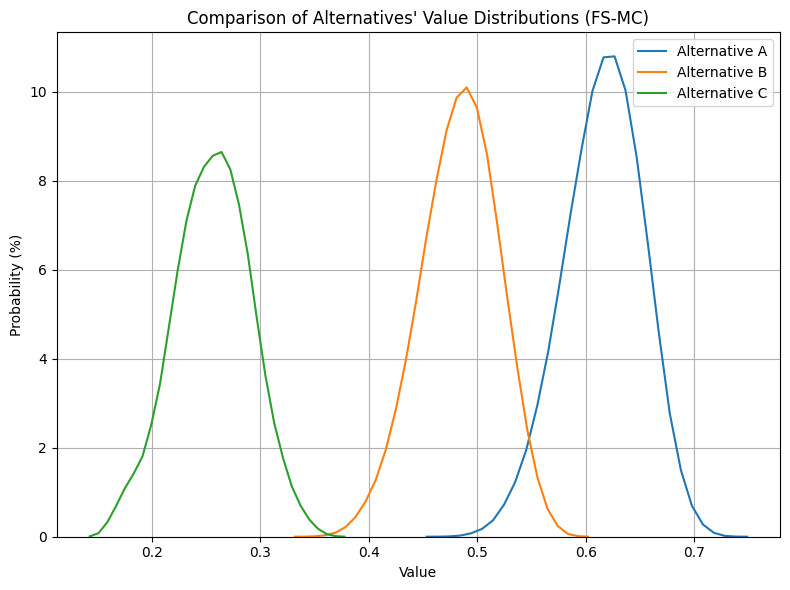

In [13]:
# Plot to compare alternatives' distributions in one figure
fig, ax = plt.subplots(figsize=(8, 6))
for alt_idx in range(len(alternatives)):
    
    data = results_MC_strict[:, alt_idx]

    hist, bin_edges = np.histogram(data, bins=30)
    hist_prob = hist / sim_runs  # probability per bin (sums to 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    ax.plot(bin_centers, hist_prob * 100, label=f'Alternative {chr(65 + alt_idx)}')
ax.set_xlabel("Value")
ax.set_ylabel("Probability (%)")
ax.set_title("Comparison of Alternatives' Value Distributions (FS-MC)")
ax.legend()
plt.ylim(0)
plt.tight_layout()
plt.grid(True)
plt.show()

In [14]:
results, rel_errs = mc_simulation(*args, strict = True, strict_d = True, weight_fixed=10)

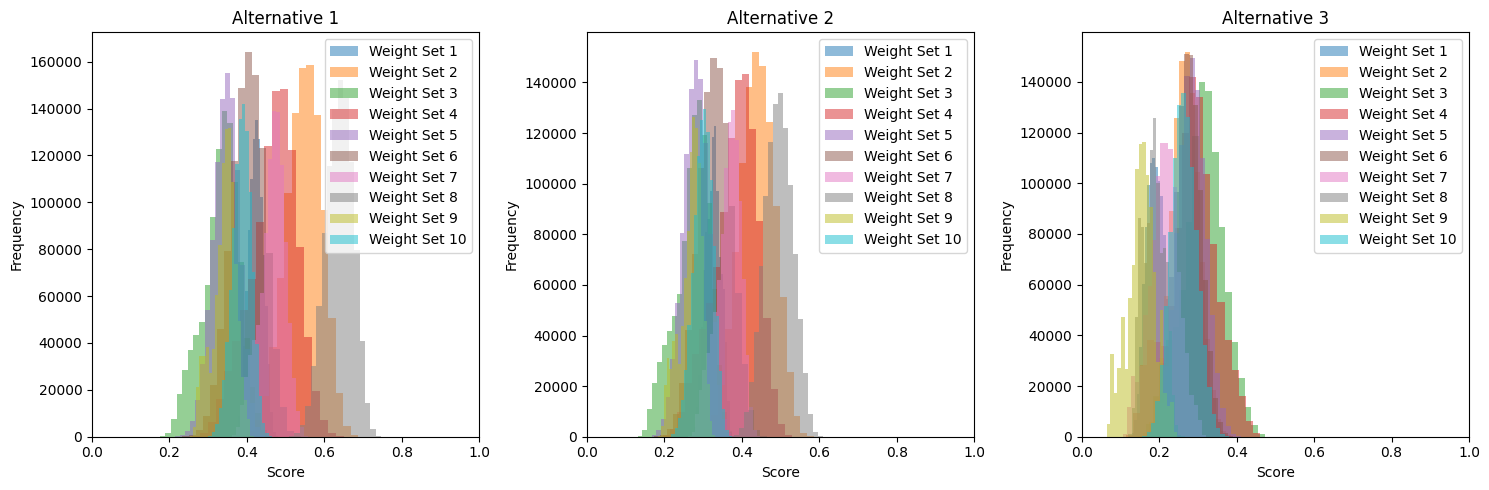

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Number of alternatives and weight sets
num_alternatives = results[0].shape[1]
num_weight_sets = len(results)

# Create a figure with subplots for each alternative
fig, axes = plt.subplots(1, num_alternatives, figsize=(5*num_alternatives, 5))
if num_alternatives == 1:
    axes = [axes]  # Ensure axes is iterable

# Plot distributions for each alternative
for alt_idx in range(num_alternatives):
    ax = axes[alt_idx]
    for weight_idx in range(num_weight_sets):
        # Extract scores for this alternative and weight set
        scores = results[weight_idx][:, alt_idx]

        # Plot as a histogram or KDE
        ax.hist(scores, bins=20, alpha=0.5, label=f'Weight Set {weight_idx+1}')

    ax.set_title(f'Alternative {alt_idx+1}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


In [16]:
num_weight_sets = len(results)
num_alternatives = results[0].shape[1]
total_runs = len(results[0])

# Initialize arrays for ranking probabilities
# Shape: (num_alternatives, max_rank, num_weight_sets) for per-set probabilities
ranking_probs_per_set = np.zeros((num_alternatives, num_alternatives, num_weight_sets))

# Shape: (num_alternatives, max_rank) for overall probabilities
overall_ranking_probs = np.zeros((num_alternatives, num_alternatives))

# Compute rankings for each weight set
for set_idx, set_results in enumerate(results):
    # Get ranks for all runs in this weight set (1 = best, num_alternatives = worst)
    ranks = np.argsort(np.argsort(set_results, axis=1), axis=1) + 1  # Shape: (sim_runs, num_alternatives)

    # Count ranking occurrences for this weight set
    for alt_idx in range(num_alternatives):
        for rank in range(1, num_alternatives + 1):
            ranking_probs_per_set[alt_idx, rank-1, set_idx] = np.mean(ranks[:, alt_idx] == rank)

    # Aggregate for overall probabilities
    for alt_idx in range(num_alternatives):
        for rank in range(1, num_alternatives + 1):
            overall_ranking_probs[alt_idx, rank-1] = np.mean(ranks[:, alt_idx] == rank)

# Normalize overall probabilities across all weight sets
overall_ranking_probs /= num_weight_sets

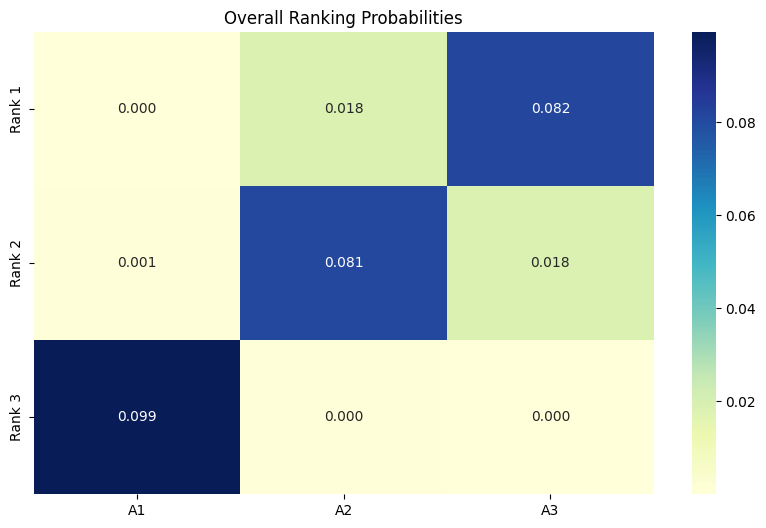

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    overall_ranking_probs.T,  # Transpose to show ranks as columns
    annot=True,
    xticklabels=[f"A{alt+1}" for alt in range(num_alternatives)],
    yticklabels=[f"Rank {r+1}" for r in range(num_alternatives)],
    cmap="YlGnBu",
    fmt=".3f"
)
plt.title("Overall Ranking Probabilities")
plt.show()


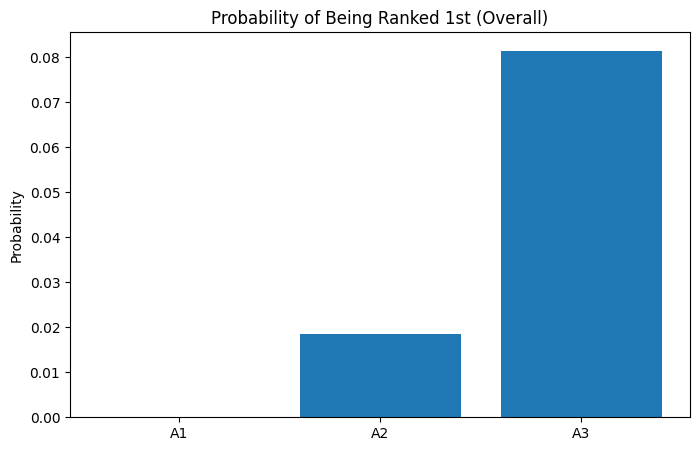

In [18]:
best_rank_probs = overall_ranking_probs[:, 0]  # Probability of being rank 1

plt.figure(figsize=(8, 5))
plt.bar(range(num_alternatives), best_rank_probs)
plt.xticks(range(num_alternatives), [f"A{alt+1}" for alt in range(num_alternatives)])
plt.title("Probability of Being Ranked 1st (Overall)")
plt.ylabel("Probability")
plt.show()
